In [ ]:
%pip install sympy
%pip install numpy
%pip install matplotlib
%pip install scipy

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import symbols, diff, simplify, init_printing
init_printing()

# Curve v1 equations
x, y, D, A = symbols("x y D A")
k = A*x*y/(D/2)**2
f = x*y + k*(x+y)*D - (D/2)**2 - k*D**2

df_dx = diff(f, x)
df_dy = diff(f, y)
dy_dx = -df_dx / df_dy

display(f)
print(simplify(dy_dx))

y*(4*A*D - 8*A*x - 4*A*y - D)/(x*(-4*A*D + 4*A*x + 8*A*y + D))


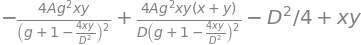

y*(32*A*D**3*g**2*x*y*(D - x - y) + 4*A*D**3*g**2*(D**2*(g + 1) - 4*x*y)*(D - 2*x - y) - (D**2*(g + 1) - 4*x*y)**3)/(x*(32*A*D**3*g**2*x*y*(-D + x + y) + 4*A*D**3*g**2*(D**2*(g + 1) - 4*x*y)*(-D + x + 2*y) + (D**2*(g + 1) - 4*x*y)**3))


In [15]:
# Curve v2 equations
x, y, D, A, g = symbols("x y D A g")
k0 = x*y/(D/2)**2
k = A*k0*g**2/(g+1-k0)**2
f = x*y + k*D*(x+y) - (D/2)**2 - k*D**2

df_dx = diff(f, x)
df_dy = diff(f, y)
dy_dx = -df_dx / df_dy

display(f)
print(simplify(dy_dx))

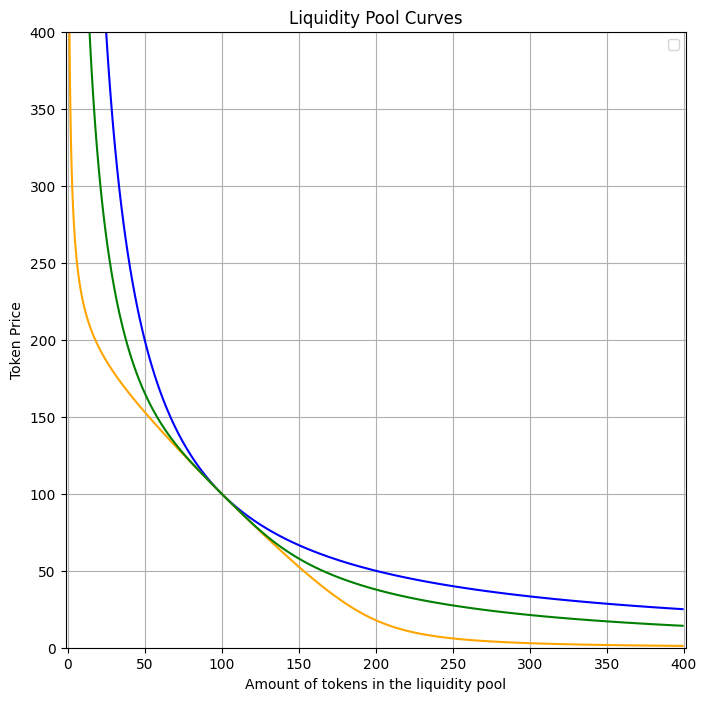

In [16]:
D = 200
A = 5
g = 0.1

xs = np.linspace(0, 400, 1000)
ys = np.linspace(0, 400, 1000)

x, y = np.meshgrid(xs, ys)

# Constant product
f_cp = x*y - (D/2)**2
# Curve v1
k = x*y/(D/2)**2
f_curve_v1 = x*y + A*k*(x+y)*D - (D/2)**2 - A*k*D**2
# Curve v2
k0 = x*y/(D/2)**2
k = A*k0*g**2/(g+1-k0)**2
f_curve_v2 = x*y + k*D*(x+y) - (D/2)**2 - k*D**2

plt.figure(figsize=(8, 8)) 
plt.axis('equal')

plt.contour(x, y, f_cp, levels=[0], colors='blue')
plt.contour(x, y, f_curve_v1, levels=[0], colors='orange')
plt.contour(x, y, f_curve_v2, levels=[0], colors='green')

plt.legend(["Constant Product", "Curve v1", "Curve v2"])

plt.xlabel("Amount of tokens in the liquidity pool")
plt.ylabel("Token Price")
plt.title("Liquidity Pool Curves")
plt.grid(True)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


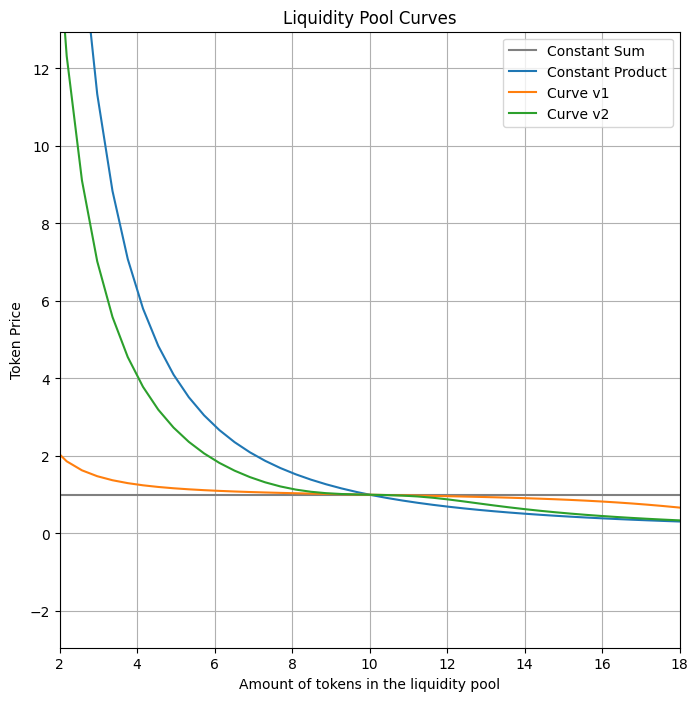

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

import warnings
warnings.simplefilter("ignore", category=Warning)

D = 20
A = 5
g = 0.05

def f_cp(y, x, D):
    return x*y - (D/2)**2

def dy_dx_cp(x, y):
    return -y/x

def f_curve_v1(y, x, A, D):
    k = A*x*y/(D/2)**2
    return x*y + k*D*(x+y) - (D/2)**2 - k*D**2
    
def dy_dx_curve_v1(x, y):
    return y*(4*A*D - 8*A*x - 4*A*y - D)/(x*(-4*A*D + 4*A*x + 8*A*y + D))

def f_curve_v2(y, x, A, D, g):
    k0 = x*y/(D/2)**2
    k = A*k0*g**2/(g+1-k0)**2
    return x*y + k*D*(x+y) - (D/2)**2 - k*D**2
    
def dy_dx_curve_v2(x, y):
    return y*(32*A*D**3*g**2*x*y*(D - x - y) + 4*A*D**3*g**2*(D**2*(g + 1) - 4*x*y)*(D - 2*x - y) - (D**2*(g + 1) - 4*x*y)**3)/(x*(32*A*D**3*g**2*x*y*(-D + x + y) + 4*A*D**3*g**2*(D**2*(g + 1) - 4*x*y)*(-D + x + 2*y) + (D**2*(g + 1) - 4*x*y)**3))

xs = np.linspace(1, 40, 100)

ys_cp = [fsolve(f_cp, D, args=(x, D))[0] for x in xs]
ps_cp = [-dy_dx_cp(x, y) for x, y in zip(xs, ys_cp)]

ys_curve_v1 = [fsolve(f_curve_v1, D, args=(x, A, D))[0] for x in xs]
ps_curve_v1 = [-dy_dx_curve_v1(x, y) for x, y in zip(xs, ys_curve_v1)]

ys_curve_v2 = [fsolve(f_curve_v2, (D/2)**2, args=(x, A, D, g))[0] for x in xs]
ps_curve_v2 = [-dy_dx_curve_v2(x, y) for x, y in zip(xs, ys_curve_v2)]

plt.figure(figsize=(8, 8)) 
plt.axis('equal')

plt.axhline(1, color = "grey")
plt.plot(xs, ps_cp)
plt.plot(xs, ps_curve_v1)
plt.plot(xs, ps_curve_v2)
plt.legend([
    "Constant Sum",
    "Constant Product", 
    "Curve v1", 
    "Curve v2"
])

plt.xlim(2, 18)
plt.ylim(0, 10)
plt.grid(True)
plt.title("Liquidity Pool Curves")
plt.xlabel("Amount of tokens in the liquidity pool")
plt.ylabel("Token Price")
plt.show()